<a href="https://colab.research.google.com/github/aphanachone/csci490/blob/main/CSCI490_SignLangaugeRecognition_09AZ_AustinPhanachone_YoloV11_Training_20Epochs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Dependencies
# ultralytics:          YOLOv11 model architecture and training loop
# roboflow:             dataset download client
# pandas, matplotlib:   read results.csv and plot training curves
# seaborn:              annotated confusion matrix heatmap
!pip install ultralytics roboflow pandas matplotlib seaborn

# Confirm GPU availability
!nvidia-smi
!lscpu | head -n 20

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
Wed Mar  4 22:02:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driv

In [2]:
# Imports
from roboflow import Roboflow       # dataset download client
from ultralytics import YOLO        # YOLOv11 model wrapper
from pathlib import Path            # clean cross-platform file paths
from PIL import Image               # image display in notebook
from IPython.display import display # renders PIL images inline
import pandas as pd                 # reads YOLO's results.csv for training curves
import matplotlib.pyplot as plt     # plotting
import seaborn as sns               # annotated confusion matrix heatmap
import numpy as np
import yaml
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# Downloads the sign language dataset from Roboflow in YOLOv11 format.
# Includes: images, labels, and a data.yaml config file that tells YOLO the class names, number of classes, and split paths.
from roboflow import Roboflow
rf = Roboflow(api_key="dDXT8TCjfy1fi2xSCTRm")
project = rf.workspace("aphanachone").project("sign-language-project-colorful-d0wkv")
version = project.version(3)
dataset = version.download("yolov11")

# Point to the data.yaml that Roboflow auto-generates.
# This file defines: nc (num classes), names (class labels), and train/val/test paths.
data_yaml = str(Path(dataset.location) / "data.yaml")
print("Using data.yaml at:", data_yaml)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sign-Language-Project-Colorful-3 in yolov11:: 100%|██████████| 7212/7212 [00:02<00:00, 2642.69it/s]

Using data.yaml at: /content/Sign-Language-Project-Colorful-3/data.yaml


In [4]:
# Model Training
# Load YOLOv11 nano pretrained on COCO — fine-tune on our sign language dataset.
# 'nano' (n) is the smallest/fastest variant; swap for 's' or 'm' if accuracy is low.
model = YOLO("yolo11n.pt")

train_result = model.train(
    data=data_yaml,             # path to dataset config (classes, splits)
    epochs=20,                  # number of full passes over the training set
    imgsz=640,                  # input resolution 640x640 — standard for YOLO
    name="sign_language_v11",   # run name; all outputs saved under runs/detect/
    plots=True                  # saves PR curve, results.csv, label plots, etc.
)

# training output directory.
run_dir = Path(train_result.save_dir)
print("Training run saved to:", run_dir)

# Validation
# Evaluate on the val split to confirm the model trained correctly.
# mAP50:    mean average precision at IoU=0.50 (lenient, standard benchmark)
# mAP50-95: mean over IoU thresholds 0.50-0.95 (stricter, better overall signal)
val_metrics = model.val()
print("Val mAP50-95:", val_metrics.box.map)
print("Val mAP50:   ", val_metrics.box.map50)

# Test Set Evaluation
test_metrics = model.val(split="test", plots=True)
test_save_dir = Path(test_metrics.save_dir)  # capture where YOLO saved the plots
print("Test mAP50-95:", test_metrics.box.map)
print("Test mAP50:   ", test_metrics.box.map50)
print("Test plots saved to:", test_save_dir)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Sign-Language-Project-Colorful-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sign_language_v11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

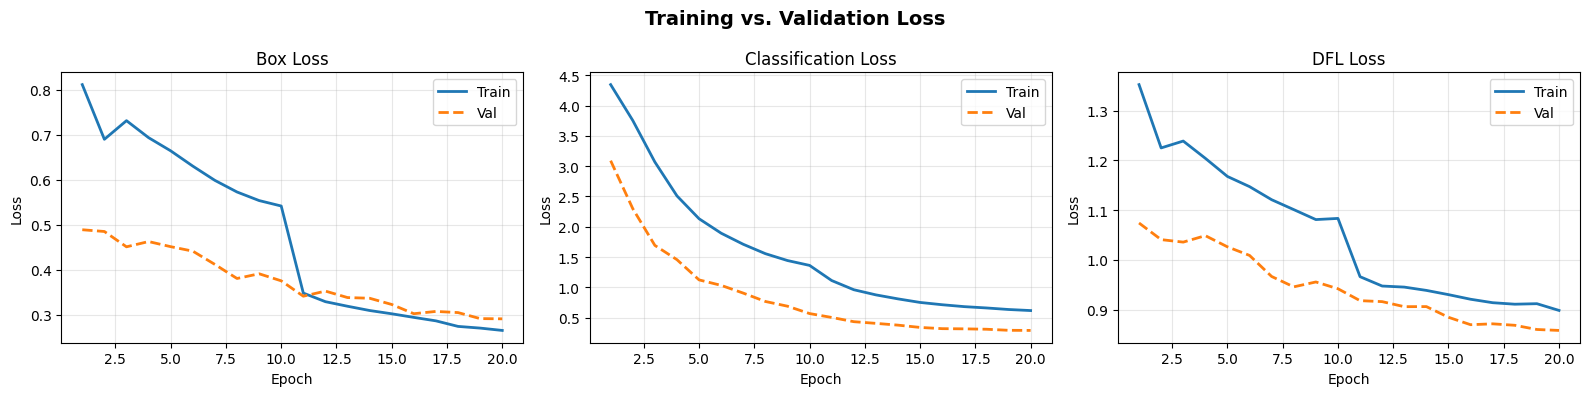

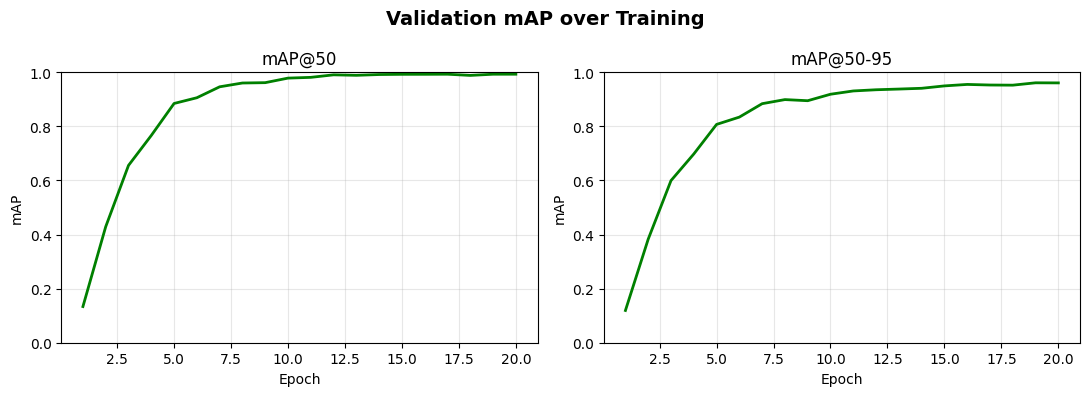

In [5]:
# Training Curves
df = pd.read_csv(run_dir / "results.csv")
df.columns = df.columns.str.strip()  # strip any whitespace from column names
epochs = df["epoch"]

# Loss curves
# box_loss: bounding box regression loss (localization accuracy)
# cls_loss: classification loss (correct sign label)
# dfl_loss: distribution focal loss (box edge precision)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training vs. Validation Loss", fontsize=14, fontweight="bold")

for ax, (train_col, val_col, title) in zip(axes, [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Classification Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
]):
    ax.plot(epochs, df[train_col], label="Train", linewidth=2)
    ax.plot(epochs, df[val_col],   label="Val",   linewidth=2, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# mAP curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Validation mAP over Training", fontsize=14, fontweight="bold")

for ax, (col, title) in zip(axes, [
    ("metrics/mAP50(B)",    "mAP@50"),
    ("metrics/mAP50-95(B)", "mAP@50-95"),
]):
    ax.plot(epochs, df[col], linewidth=2, color="green")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

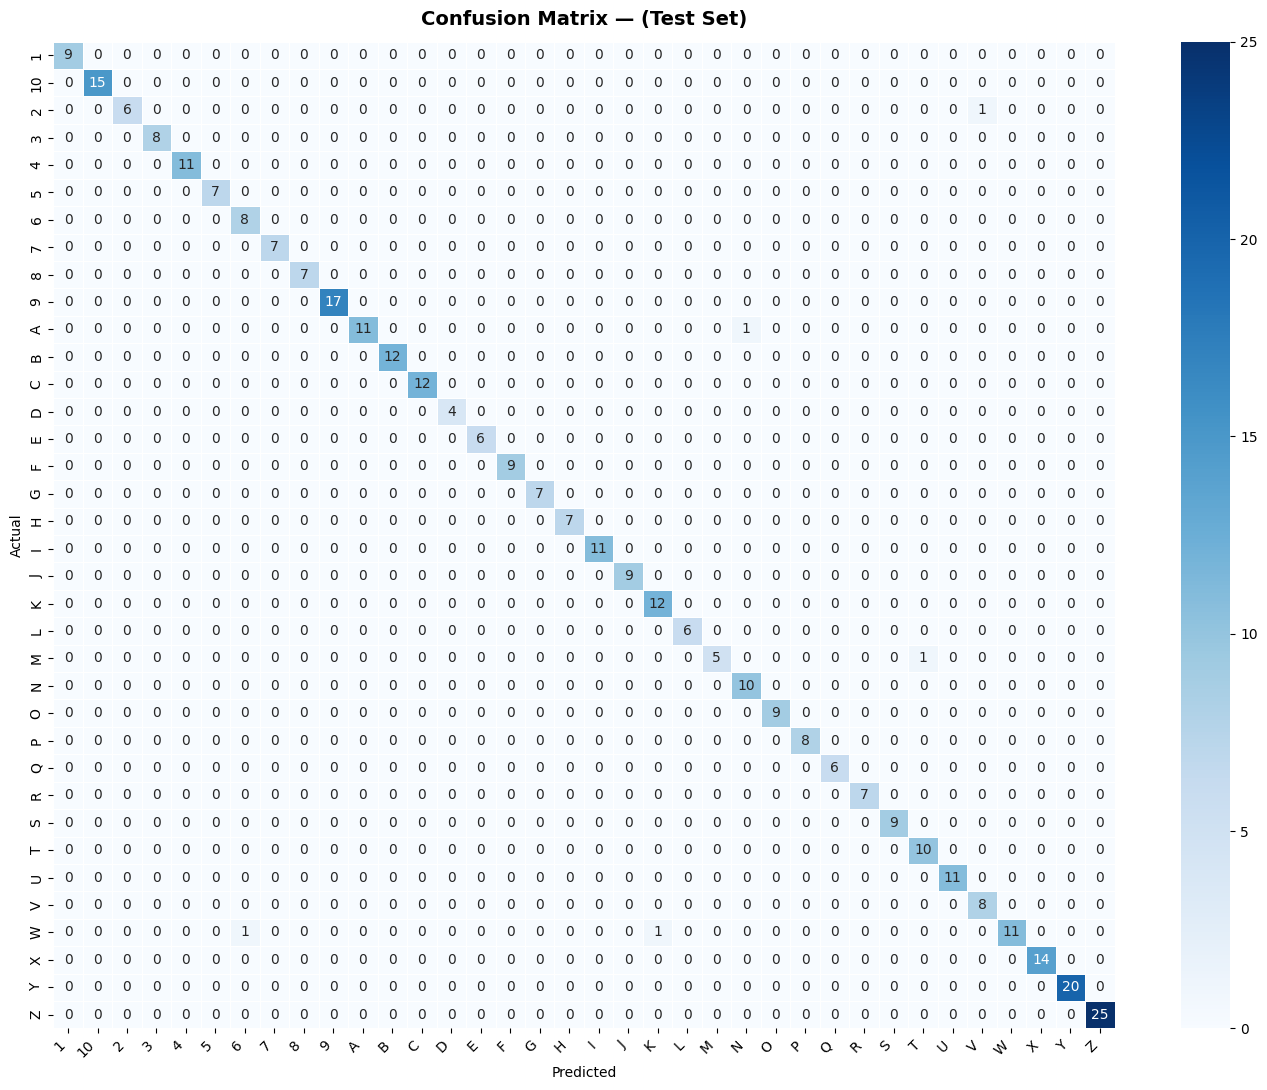

In [6]:
# Confusion Matrix (Test Set)
# Load class names from data.yaml
with open(data_yaml, "r") as f:
    class_names = yaml.safe_load(f)["names"]

cm_raw = test_metrics.confusion_matrix.matrix
cm = cm_raw[:len(class_names), :len(class_names)].astype(int)

plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.4, linecolor="white")
plt.title("Confusion Matrix — (Test Set)", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

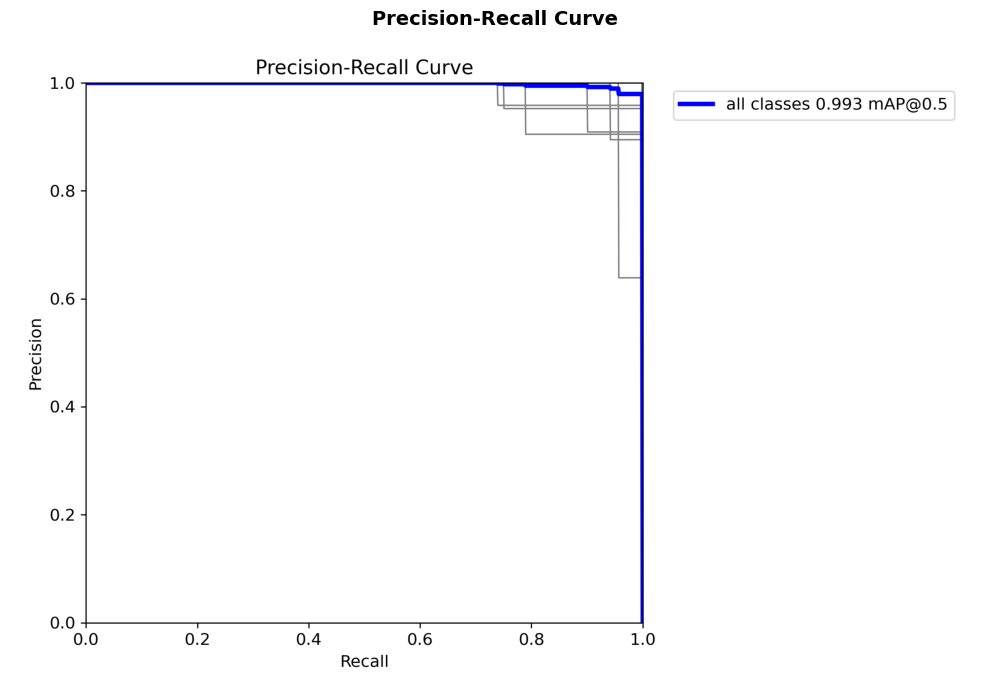

In [7]:
# Precision-Recall Curve
pr_path = run_dir / "BoxPR_curve.png"
img = Image.open(pr_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

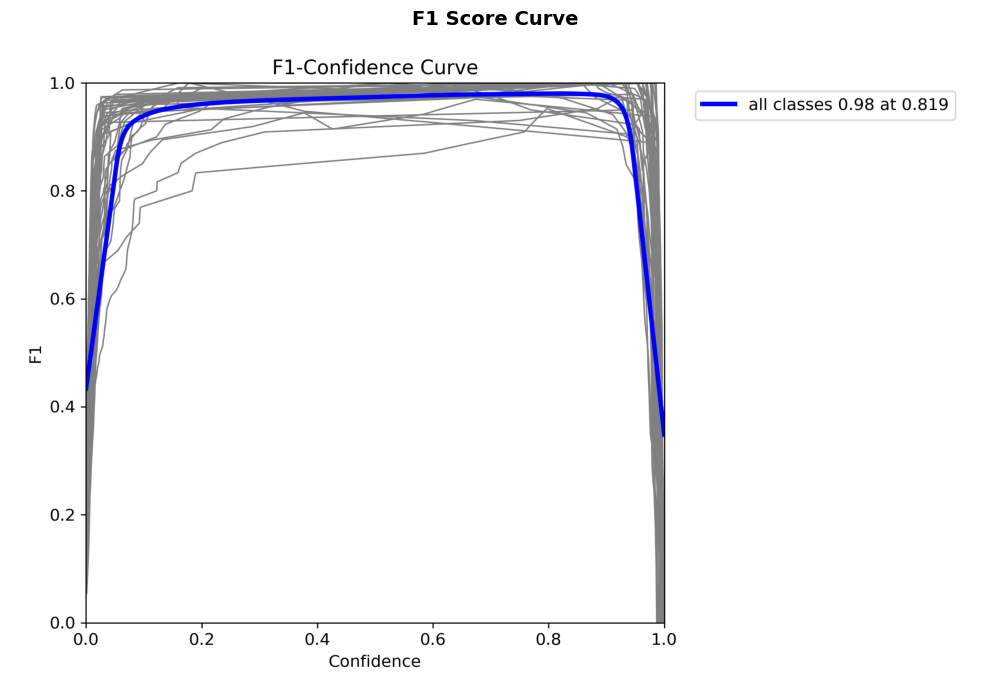

In [8]:
# F1 Score Curve

f1_path = run_dir / "BoxF1_curve.png"
img = Image.open(f1_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Score Curve", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

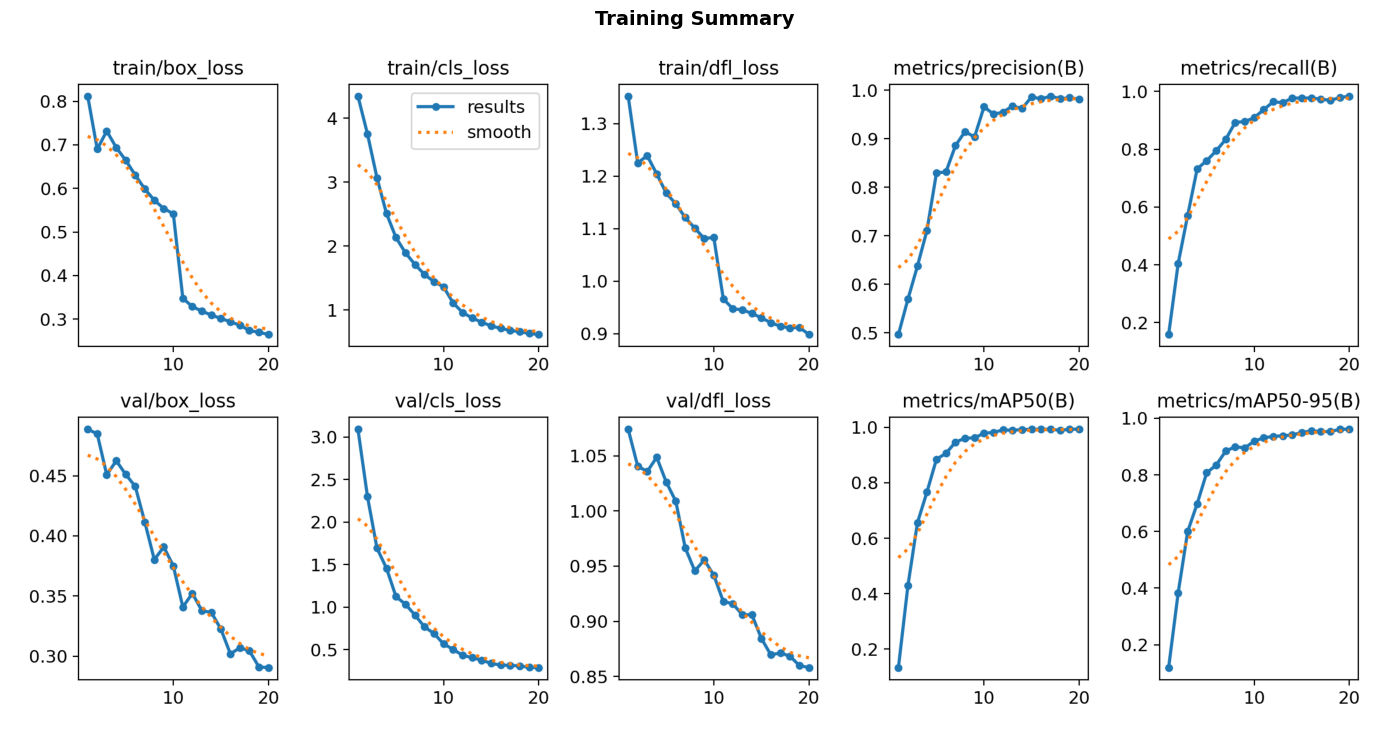

In [9]:
# Training Summary
results_img_path = run_dir / "results.png"
img = Image.open(results_img_path)

plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Training Summary", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

In [10]:
# Qualitative Testing Setup
# Runs inference on a single image and displays the result inline.
def show_prediction(model, img_path):
    results = model(img_path)
    plotted = results[0].plot()               # returns annotated BGR numpy array
    img = Image.fromarray(plotted[..., ::-1]) # convert BGR -> RGB for PIL
    display(img)

# Auto-select up to 10 test images, one per unique class.
# This gives a broad qualitative view across all sign categories.
test_labels_dir = Path(dataset.location) / "test" / "labels"
test_images_dir = Path(dataset.location) / "test" / "images"

chosen_images = []
seen_classes  = set()

for label_path in sorted(test_labels_dir.glob("*.txt")):
    with open(label_path, "r") as f:
        first_line = f.readline().strip()
    if not first_line:
        continue  # skip empty label files (background images)

    cls_id = int(first_line.split()[0])  # first token in YOLO label = class index
    if cls_id in seen_classes:
        continue  # already have a sample for this class

    seen_classes.add(cls_id)
    stem = label_path.stem

    # Match label file to its corresponding image (any common extension)
    img_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = test_images_dir / f"{stem}{ext}"
        if candidate.exists():
            img_path = candidate
            break

    if img_path is not None:
        chosen_images.append(img_path)

    if len(chosen_images) >= 10:
        break

print(f"Selected {len(chosen_images)} images for qualitative tests.")
for p in chosen_images:
    print(p)

Selected 10 images for qualitative tests.
/content/Sign-Language-Project-Colorful-3/test/images/0e45c8dc-e80f-482a-9d03-1338ae37c9d6-rgb_0000_png.rf.b563aff1b68222ee1886ad5425c89ab7.jpg
/content/Sign-Language-Project-Colorful-3/test/images/16b1db0d-ecd6-4f07-9435-19a209c3e2b9-rgb_0000_png.rf.b15801fe57411c1db12de0434a5416ab.jpg
/content/Sign-Language-Project-Colorful-3/test/images/1_e1bfcbc8-dc6f-11ed-ae59-b07d6448fdf4_png.rf.0b45f9a0de9c7834a549a91dc6113f9b.jpg
/content/Sign-Language-Project-Colorful-3/test/images/2_e1c25462-dc6f-11ed-bc08-b07d6448fdf4_png.rf.03e3476c6847adab63df42bbbac86060.jpg
/content/Sign-Language-Project-Colorful-3/test/images/3_e1c41de8-dc6f-11ed-a36a-b07d6448fdf4_png.rf.17834f445ba4de5c27292393cdb4b54e.jpg
/content/Sign-Language-Project-Colorful-3/test/images/4_e1c6f2aa-dc6f-11ed-b98d-b07d6448fdf4_png.rf.3e3735a0e4c25968db1331a798b194a3.jpg
/content/Sign-Language-Project-Colorful-3/test/images/5_e1c908b2-dc6f-11ed-a62e-b07d6448fdf4_png.rf.dbb0e1e5341c6d243093bc

Image: /content/Sign-Language-Project-Colorful-3/test/images/0e45c8dc-e80f-482a-9d03-1338ae37c9d6-rgb_0000_png.rf.b563aff1b68222ee1886ad5425c89ab7.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/0e45c8dc-e80f-482a-9d03-1338ae37c9d6-rgb_0000_png.rf.b563aff1b68222ee1886ad5425c89ab7.jpg: 640x640 1 9, 10.1ms
Speed: 1.9ms preprocess, 10.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


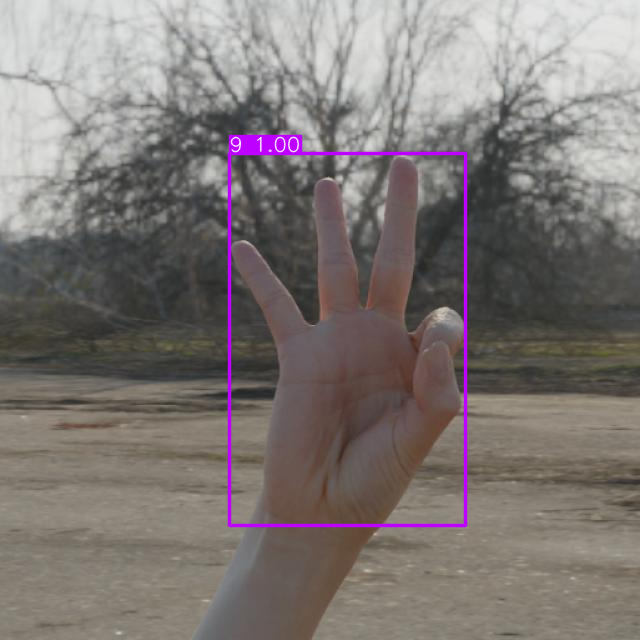

Image: /content/Sign-Language-Project-Colorful-3/test/images/16b1db0d-ecd6-4f07-9435-19a209c3e2b9-rgb_0000_png.rf.b15801fe57411c1db12de0434a5416ab.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/16b1db0d-ecd6-4f07-9435-19a209c3e2b9-rgb_0000_png.rf.b15801fe57411c1db12de0434a5416ab.jpg: 640x640 1 10, 11.2ms
Speed: 1.8ms preprocess, 11.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


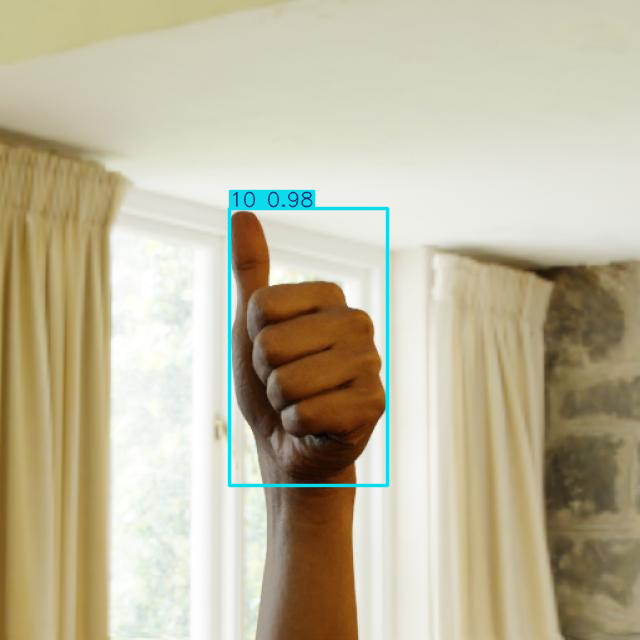

Image: /content/Sign-Language-Project-Colorful-3/test/images/1_e1bfcbc8-dc6f-11ed-ae59-b07d6448fdf4_png.rf.0b45f9a0de9c7834a549a91dc6113f9b.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/1_e1bfcbc8-dc6f-11ed-ae59-b07d6448fdf4_png.rf.0b45f9a0de9c7834a549a91dc6113f9b.jpg: 640x640 1 1, 16.3ms
Speed: 3.7ms preprocess, 16.3ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)


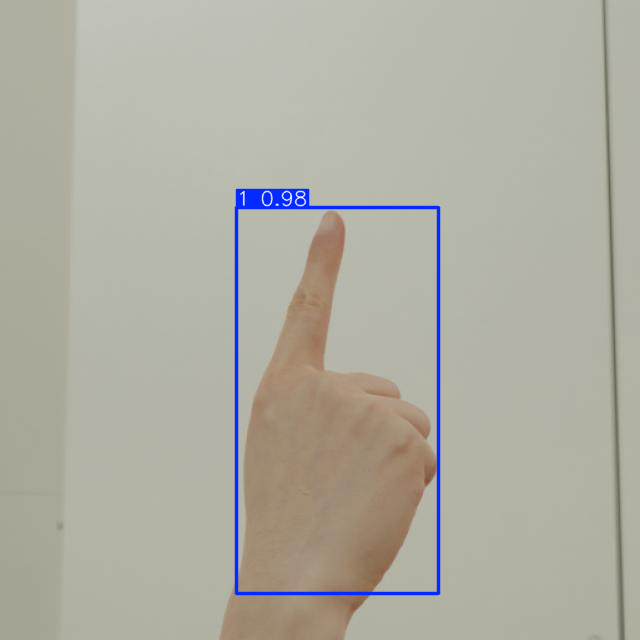

Image: /content/Sign-Language-Project-Colorful-3/test/images/2_e1c25462-dc6f-11ed-bc08-b07d6448fdf4_png.rf.03e3476c6847adab63df42bbbac86060.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/2_e1c25462-dc6f-11ed-bc08-b07d6448fdf4_png.rf.03e3476c6847adab63df42bbbac86060.jpg: 640x640 1 2, 12.1ms
Speed: 2.1ms preprocess, 12.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


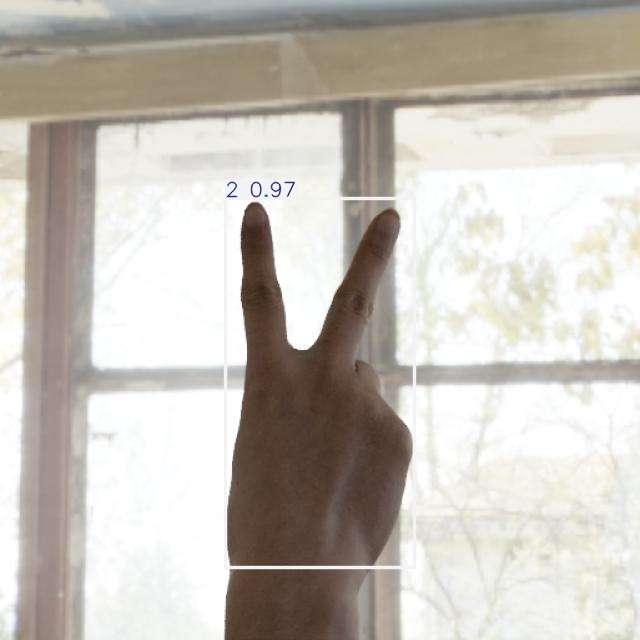

Image: /content/Sign-Language-Project-Colorful-3/test/images/3_e1c41de8-dc6f-11ed-a36a-b07d6448fdf4_png.rf.17834f445ba4de5c27292393cdb4b54e.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/3_e1c41de8-dc6f-11ed-a36a-b07d6448fdf4_png.rf.17834f445ba4de5c27292393cdb4b54e.jpg: 640x640 1 3, 13.3ms
Speed: 2.2ms preprocess, 13.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


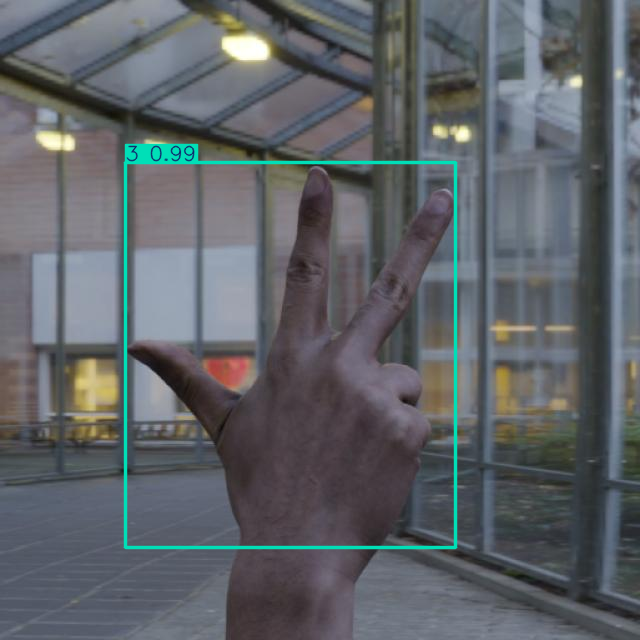

Image: /content/Sign-Language-Project-Colorful-3/test/images/4_e1c6f2aa-dc6f-11ed-b98d-b07d6448fdf4_png.rf.3e3735a0e4c25968db1331a798b194a3.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/4_e1c6f2aa-dc6f-11ed-b98d-b07d6448fdf4_png.rf.3e3735a0e4c25968db1331a798b194a3.jpg: 640x640 1 4, 18.7ms
Speed: 4.2ms preprocess, 18.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


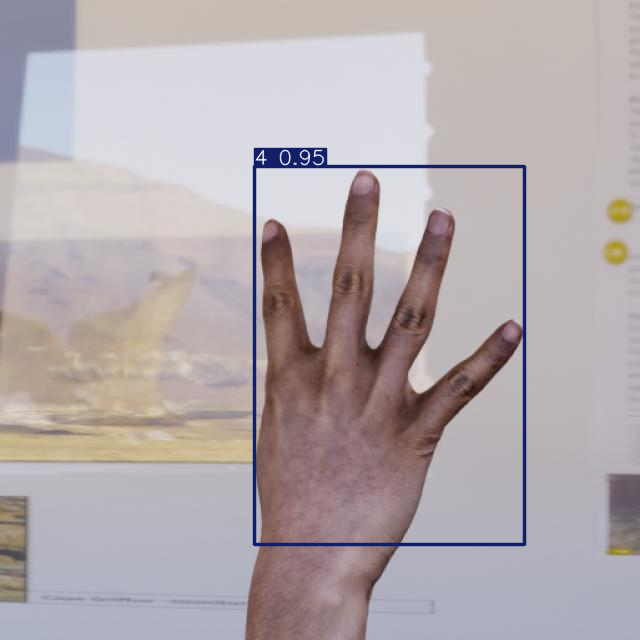

Image: /content/Sign-Language-Project-Colorful-3/test/images/5_e1c908b2-dc6f-11ed-a62e-b07d6448fdf4_png.rf.dbb0e1e5341c6d243093bcc8e3fbb770.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/5_e1c908b2-dc6f-11ed-a62e-b07d6448fdf4_png.rf.dbb0e1e5341c6d243093bcc8e3fbb770.jpg: 640x640 1 5, 12.1ms
Speed: 2.1ms preprocess, 12.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


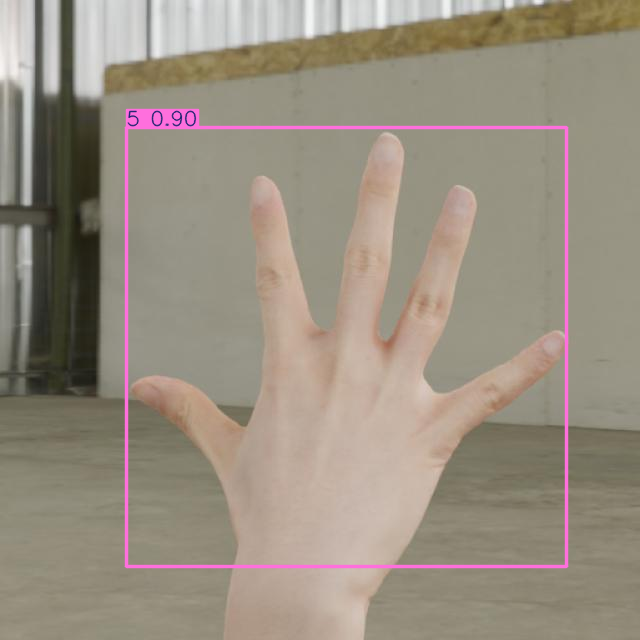

Image: /content/Sign-Language-Project-Colorful-3/test/images/6_e1cb1ece-dc6f-11ed-a923-b07d6448fdf4_png.rf.8402042f281739c2f60d6bfc60013a30.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/6_e1cb1ece-dc6f-11ed-a923-b07d6448fdf4_png.rf.8402042f281739c2f60d6bfc60013a30.jpg: 640x640 1 6, 12.3ms
Speed: 2.0ms preprocess, 12.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


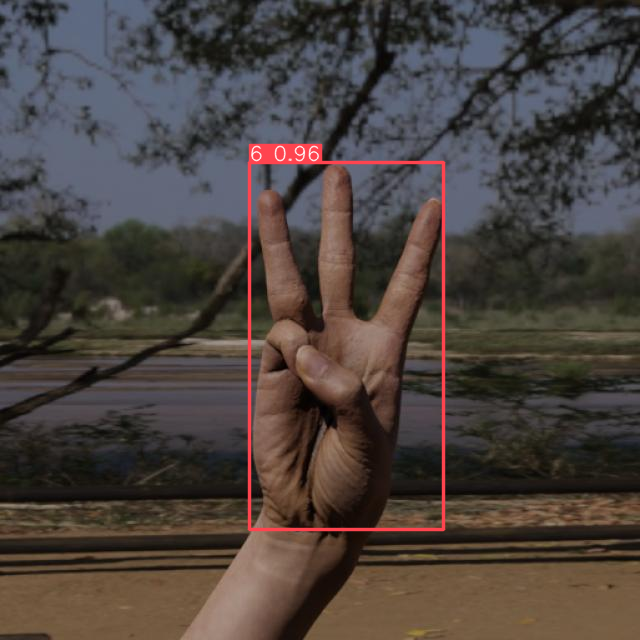

Image: /content/Sign-Language-Project-Colorful-3/test/images/7_e1cd8120-dc6f-11ed-ae86-b07d6448fdf4_png.rf.b45342c0cd328f131d93d24168cd80d2.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/7_e1cd8120-dc6f-11ed-ae86-b07d6448fdf4_png.rf.b45342c0cd328f131d93d24168cd80d2.jpg: 640x640 1 7, 11.1ms
Speed: 2.0ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


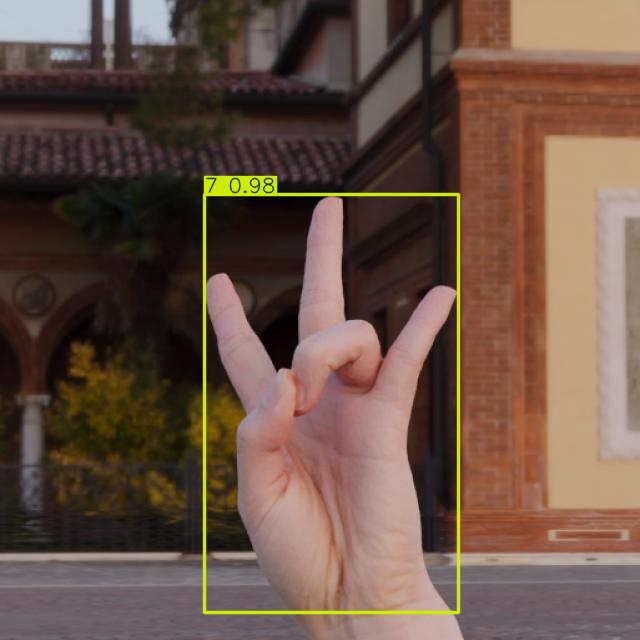

Image: /content/Sign-Language-Project-Colorful-3/test/images/8_e1cfbd35-dc6f-11ed-b946-b07d6448fdf4_png.rf.872cc46c00b3c42ce468d4a3c2d4e6a2.jpg

image 1/1 /content/Sign-Language-Project-Colorful-3/test/images/8_e1cfbd35-dc6f-11ed-b946-b07d6448fdf4_png.rf.872cc46c00b3c42ce468d4a3c2d4e6a2.jpg: 640x640 1 8, 11.1ms
Speed: 2.2ms preprocess, 11.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


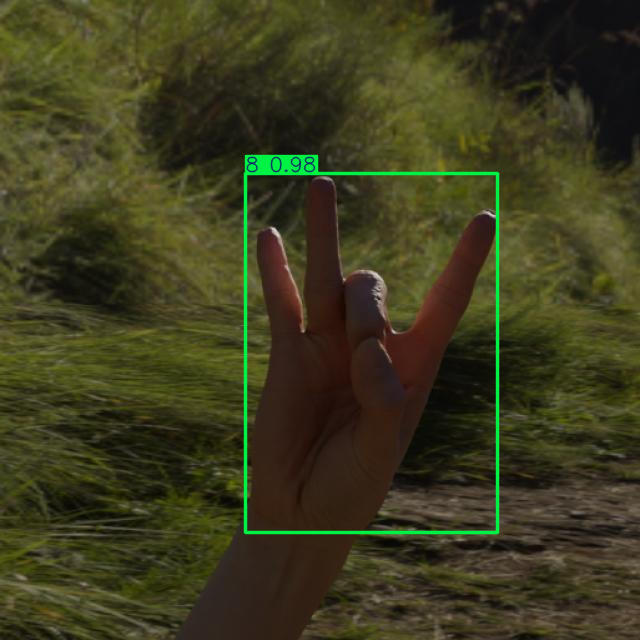

In [11]:
# Run inference on each selected test image and display the bounding-box overlay.
for img_path in chosen_images:
    print("Image:", img_path)
    show_prediction(model, str(img_path))

In [ ]:
# Upload any image from your computer
from google.colab import files

print("Select an image file to upload...")
uploaded = files.upload()

for filename, data in uploaded.items():
    # Save uploaded bytes to disk so YOLO can read it
    upload_path = f"/tmp/{filename}"
    with open(upload_path, "wb") as f:
        f.write(data)

    # Run inference — verbose=False suppresses YOLO's per-frame console output
    results = model(upload_path, verbose=False)
    r = results[0]

    # Annotated image
    annotated = Image.fromarray(r.plot()[..., ::-1])  # BGR -> RGB
    print(f"\n── {filename} ──")
    display(annotated)

    # Confidence breakdown
    # r.boxes holds all detections; each has a class index and confidence score.
    # We sort by confidence descending so the strongest detections appear first.
    if r.boxes is None or len(r.boxes) == 0:
        print("No signs detected. Try a clearer or better-lit image.")
    else:
        detections = []
        for box in r.boxes:
            cls_id    = int(box.cls.item())          # class index
            conf      = float(box.conf.item())       # confidence score (0-1)
            label     = r.names[cls_id]              # human-readable class name
            detections.append((label, conf))

        # Sort strongest confidence first
        detections.sort(key=lambda x: x[1], reverse=True)

        print("Detections:")
        for label, conf in detections:
            bar = "█" * int(conf * 20)               # simple ASCII confidence bar
            print(f"  {label:<6}  {conf*100:5.1f}%  {bar}")

Select an image file to upload...
